# Communities Detection

## Libs install

In [1]:
import os
import networkx as nx
import statistics
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.cluster import SpectralClustering
from cdlib import algorithms

Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'wurlitzer', 'bayanpy', 'infomap'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


In [2]:
code_theme = 70

G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)

positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
G_positive = nx.Graph()
G_positive.add_nodes_from(G.nodes(data=True))
G_positive.add_edges_from(positive_edges)

## Leidein

In [3]:
coms = algorithms.leiden(G_positive)

In [6]:
def leiden_to_dict(communities):
    return {node: i 
            for i, community in enumerate(communities.communities) 
            for node in community}

In [6]:
coms_leiden = leiden_to_dict(coms)

In [ ]:
coms_leiden

## Label Propagation

In [28]:
import random

def signed_label_propagation(G, max_iter=100):
    # Cada nó começa com sua própria comunidade
    # Usamos o próprio nó como rótulo inicial
    labels = {node: node for node in G.nodes()}
    
    for _ in range(max_iter):
        # Iteramos sobre os nós em ordem aleatória
        # para evitar viés de ordem de atualização
        nodes = list(G.nodes())
        random.shuffle(nodes)
        
        changed = False
        for node in nodes:
            # Acumulamos o "peso" de cada comunidade vizinha
            # levando em conta o sinal da aresta
            community_weights = {}
            for neighbor in G.neighbors(node):
                weight = G[node][neighbor].get('weight', 0)
                neighbor_label = labels[neighbor]
                
                if neighbor_label not in community_weights:
                    community_weights[neighbor_label] = 0
                # Peso positivo reforça a comunidade do vizinho
                # Peso negativo penaliza a comunidade do vizinho
                community_weights[neighbor_label] += weight
            
            if not community_weights:
                continue
            
            # Adota a comunidade com maior peso acumulado
            best_label = max(community_weights, key=community_weights.get)
            
            if best_label != labels[node]:
                labels[node] = best_label
                changed = True
        
        # Se nenhum nó mudou de comunidade, convergiu
        if not changed:
            break
    
    # Converte para o formato padrão do NetworkX:
    # dicionário {nó: id_comunidade}
    # Remapeamos os rótulos para inteiros sequenciais
    unique_labels = {label: idx for idx, label in enumerate(set(labels.values()))}
    return {node: unique_labels[label] for node, label in labels.items()}

In [29]:
coms_label = signed_label_propagation(G)

In [ ]:
coms_label

## Spectral Clustering

In [8]:
nodes = list(G.nodes())
G_matrix = nx.to_numpy_array(G_positive, nodelist=nodes)

In [10]:
clustering = SpectralClustering(n_clusters=len(coms.communities)).fit(G_matrix)

In [8]:
def spectral_to_dict(labels, nodes):
    return {node: int(label) 
            for node, label in zip(nodes, labels)}

In [13]:
coms_spectral = spectral_to_dict(clustering.labels_, nodes)

In [ ]:
coms_spectral

## Iterate Over Each Theme

In [2]:
import duckdb
import json

duckdb_path = os.getenv("DUCKDB_PATH")
assert duckdb_path is not None, "Variable 'DUCKDB_PATH' must be defined"

con = duckdb.connect(duckdb_path)

In [3]:
themes = con.execute("""
    SELECT
        pt.codTema as code,
        pt.tema as theme,
        COALESCE(SUM(pp.polls_count), 0)::INT as polls_count
    FROM proposicoesTemas pt
    LEFT JOIN (
        SELECT
            vo.proposicao_id,
            COUNT(vo.idVotacao) as polls_count
        FROM votacoesObjetos vo
        JOIN votacoesVotos vv ON vv.idVotacao = vo.idVotacao
        GROUP BY vo.proposicao_id
    ) pp ON pp.proposicao_id = pt.proposicao_id
    GROUP BY 1, 2
    ORDER BY 3 DESC
""").df()

voted_themes = themes[themes['polls_count'] > 0]

voted_themes

,code,theme,polls_count
0,34,Administração Pública,16661
1,70,Finanças Públicas e Orçamento,11161
2,40,Economia,6431
3,51,Estrutura Fundiária,3946
4,44,Direitos Humanos e Minorias,3126
5,67,Direito e Defesa do Consumidor,3126
6,54,"Energia, Recursos Hídricos e Minerais",3126
7,42,Direito Civil e Processual Civil,2901
8,66,"Indústria, Comércio e Serviços",2370
9,56,Saúde,2011


In [30]:
labels_dict = dict()

for theme in voted_themes.itertuples():
    code_theme = theme.code

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)
    
    coms_label = signed_label_propagation(G_positive)

    labels_dict[code_theme] = coms_label

with open("../graphs/communities/labels.json", "w") as file:
    json.dump(labels_dict, file, indent=4)

In [10]:
leiden_dict = dict()

for theme in voted_themes.itertuples():
    code_theme = theme.code

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)

    coms = algorithms.leiden(G_positive)
    coms_leiden = leiden_to_dict(coms)
    
    leiden_dict[code_theme] = coms_leiden

with open("../graphs/communities/leiden.json", "w") as file:
    json.dump(leiden_dict, file, indent=4)

In [140]:
spectral_dict = dict()

for theme in voted_themes.itertuples():
    code_theme = theme.code

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')

    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)

    nodes = list(G_positive.nodes())
    G_matrix = nx.to_numpy_array(G_positive, nodelist=nodes)

    clustering = SpectralClustering(n_clusters=len(set(leiden_dict[code_theme].values())), affinity='precomputed').fit(G_matrix)

    coms_spectral = spectral_to_dict(clustering.labels_, nodes)
    
    spectral_dict[code_theme] = coms_spectral

with open("../graphs/communities/spectral.json", "w") as file:
    json.dump(spectral_dict, file, indent=4)

## Communities modularity

In [31]:
communities_dict = dict()

with open("../graphs/communities/labels.json", "r") as file:
    communities_dict['label_propagation'] = json.load(file)

with open("../graphs/communities/leiden.json", "r") as file:
    communities_dict['leiden'] = json.load(file)

with open("../graphs/communities/spectral.json", "r") as file:
    communities_dict['spectral'] = json.load(file)

In [32]:
def communities_dict_to_list(comms_dict):
    communities_list = [set()]
    for key in comms_dict.keys():
        value = comms_dict[key]
        if (value + 1 > len(communities_list)):
            communities_list.extend(set() for _ in range(value + 1 - len(communities_list)))
    
        communities_list[value].add(key)
    
    return communities_list

In [33]:
modularities = {
    'label_propagation': {},
    'leiden': {},
    'spectral': {}
}

In [34]:
for theme in voted_themes.itertuples():
    code_theme = theme.code
    name_theme = theme.theme

    G = nx.read_gexf(f'../graphs/theme_normalized/normalized_{code_theme}.gexf')
    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)

    positive_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    G_positive = nx.Graph()
    G_positive.add_nodes_from(G.nodes(data=True))
    G_positive.add_edges_from(positive_edges)

    for method in communities_dict.keys():
        theme_dict = communities_dict[method][f'{code_theme}']
    
        comm_list = communities_dict_to_list(theme_dict)

        modularity = nx.community.modularity(G_positive, comm_list)

        modularities[method][name_theme] = modularity

In [35]:
modularities_df = pd.DataFrame(modularities)

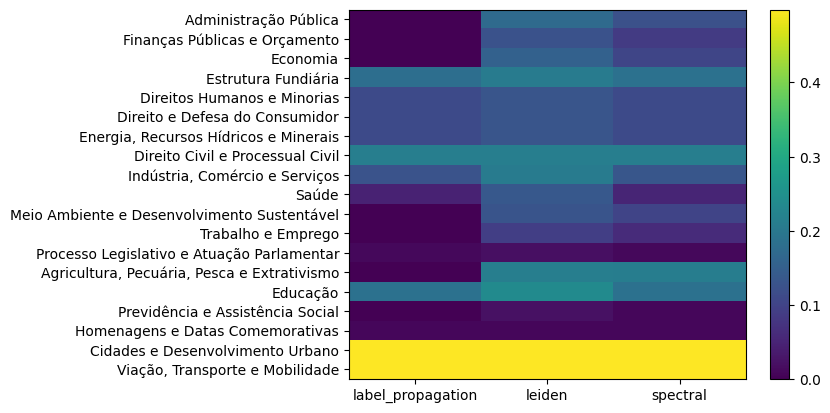

In [37]:
plt.imshow(modularities_df.values, aspect='auto')
plt.xticks(range(len(modularities_df.columns)), modularities_df.columns)
plt.yticks(range(len(modularities_df.index)), modularities_df.index)
plt.colorbar()

In [12]:
common_polls = con.execute("""
SELECT 
    pt.codTema,
    pt.tema,
    array_agg(DISTINCT vo.idVotacao ORDER BY vo.idVotacao) as votacoes
FROM votacoesObjetos vo
JOIN proposicoesTemas pt ON vo.proposicao_id = pt.proposicao_id
GROUP BY pt.codTema, pt.tema
ORDER BY votacoes
""").df()

In [13]:
common_polls["votacoes_tuple"] = common_polls["votacoes"].apply(tuple)

identical_themes = common_polls.groupby("votacoes_tuple").agg({
    "codTema": list,
    "tema": list
}).reset_index()

identical_grouped = identical_themes[identical_themes["tema"].apply(len) > 1]

In [16]:
identical_grouped

,votacoes_tuple,codTema,tema


## NVI Analysis

In [14]:
from sklearn.metrics import normalized_mutual_info_score
import seaborn as sns

In [38]:
with open("../graphs/communities/labels.json", "r") as file:
    comms_label = json.load(file)

with open("../graphs/communities/leiden.json", "r") as file:
    comms_leiden = json.load(file)

with open("../graphs/communities/spectral.json", "r") as file:
    comms_spectral = json.load(file)

themes_keys = list(comms_leiden.keys())

In [39]:
nmi_algorithm_results = []

for theme in voted_themes.itertuples():
    code_theme = theme.code
    name_theme = theme.theme
    
    nodes = list(comms_leiden[f'{code_theme}'].keys())
    labels_lp = [comms_label.get(f'{code_theme}', {}).get(n, -1) for n in nodes]
    labels_lei = [comms_leiden.get(f'{code_theme}', {}).get(n, -1) for n in nodes]
    labels_spe = [comms_spectral.get(f'{code_theme}', {}).get(n, -1) for n in nodes]
    
    nmi_lp_lei = normalized_mutual_info_score(labels_lp, labels_lei)
    nmi_lp_spe = normalized_mutual_info_score(labels_lp, labels_spe)
    nmi_lei_spe = normalized_mutual_info_score(labels_lei, labels_spe)
    
    nmi_algorithm_results.append({
        'Theme': name_theme,
        'LPA vs Leiden': nmi_lp_lei,
        'LPA vs Spectral': nmi_lp_spe,
        'Leiden vs Spectral': nmi_lei_spe
    })

In [17]:
nmi_algorithm_results

[{'Theme': 'Administração Pública',
  'LPA vs Leiden': 0.0,
  'LPA vs Spectral': 0.0,
  'Leiden vs Spectral': 0.38544516710895216},
 {'Theme': 'Finanças Públicas e Orçamento',
  'LPA vs Leiden': 0.0,
  'LPA vs Spectral': 0.0,
  'Leiden vs Spectral': 0.4626491369376458},
 {'Theme': 'Economia',
  'LPA vs Leiden': 0.0,
  'LPA vs Spectral': 0.0,
  'Leiden vs Spectral': 0.44791726722606207},
 {'Theme': 'Estrutura Fundiária',
  'LPA vs Leiden': 0.6050260602944484,
  'LPA vs Spectral': 0.9000533184872127,
  'Leiden vs Spectral': 0.6428270761360081},
 {'Theme': 'Direitos Humanos e Minorias',
  'LPA vs Leiden': 0.6751905553901306,
  'LPA vs Spectral': 1.0,
  'Leiden vs Spectral': 0.6751905553901307},
 {'Theme': 'Direito e Defesa do Consumidor',
  'LPA vs Leiden': 0.6751905553901306,
  'LPA vs Spectral': 1.0,
  'Leiden vs Spectral': 0.6751905553901306},
 {'Theme': 'Energia, Recursos Hídricos e Minerais',
  'LPA vs Leiden': 0.6751905553901306,
  'LPA vs Spectral': 1.0,
  'Leiden vs Spectral': 0.6

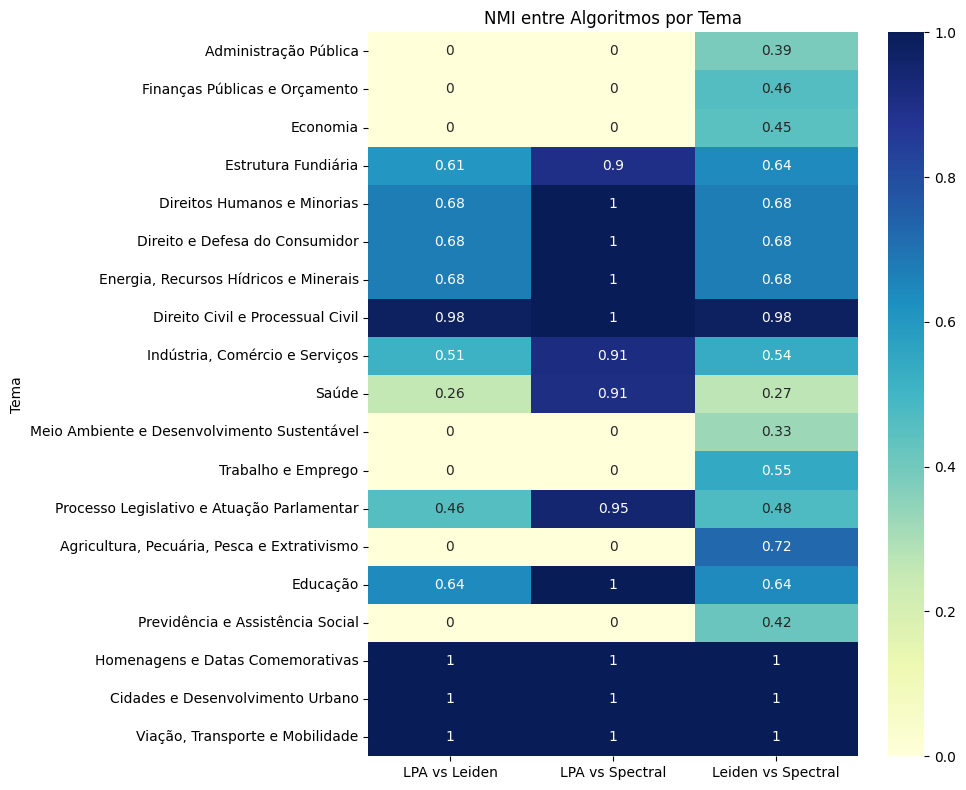

In [40]:
df_nmi_algos = pd.DataFrame(nmi_algorithm_results).set_index('Theme')
plt.figure(figsize=(10, 8))
sns.heatmap(df_nmi_algos, annot=True, cmap='YlGnBu')
plt.title("NMI entre Algoritmos por Tema")
plt.ylabel("Tema")
plt.tight_layout()
plt.show()

In [19]:
df_parties = con.execute("""
    SELECT DISTINCT
        CONCAT('d_', vv.deputado_id) as node_id,
        vv.deputado_siglaPartido as party,
    FROM votacoesVotos vv
    INNER JOIN (
        SELECT
            deputado_id,
            MAX(dataHoraVoto) as ultima_votacao
        FROM votacoesVotos
        GROUP BY deputado_id
    ) ultimo on vv.deputado_id = ultimo.deputado_id
        AND vv.dataHoraVoto = ultimo.ultima_votacao
""").df()

In [23]:
df_parties

,node_id,party
0,d_220634,PSB
1,d_204449,PL
2,d_204396,PP
3,d_141391,CIDADANIA
4,d_234788,REDE
...,...,...
616,d_123086,PP
617,d_178908,PL
618,d_220658,PSD
619,d_178934,PP


In [20]:
unique_parties = df_parties['party'].unique()
party_to_id = {party: idx for idx, party in enumerate(unique_parties)}
node_to_party_id = {row['node_id']: party_to_id[row['party']] for _, row in df_parties.iterrows()}

In [41]:
nmi_parties_results = []

for theme in voted_themes.itertuples():
    code_theme = theme.code
    name_theme = theme.theme
    nodes = list(comms_leiden[f'{code_theme}'].keys())

    valid_nodes = [n for n in nodes if n in node_to_party_id]
    if not valid_nodes:
        continue
        
    labels_true_party = [node_to_party_id[n] for n in valid_nodes]
    
    labels_lp = [comms_label.get(f'{code_theme}', {}).get(n, -1) for n in valid_nodes]
    labels_lei = [comms_leiden.get(f'{code_theme}', {}).get(n, -1) for n in valid_nodes]
    labels_spe = [comms_spectral.get(f'{code_theme}', {}).get(n, -1) for n in valid_nodes]
    
    nmi_parties_results.append({
        'Theme': name_theme,
        'LPA Valid': normalized_mutual_info_score(labels_true_party, labels_lp),
        'Leiden Valid': normalized_mutual_info_score(labels_true_party, labels_lei),
        'Spectral Valid': normalized_mutual_info_score(labels_true_party, labels_spe)
    })

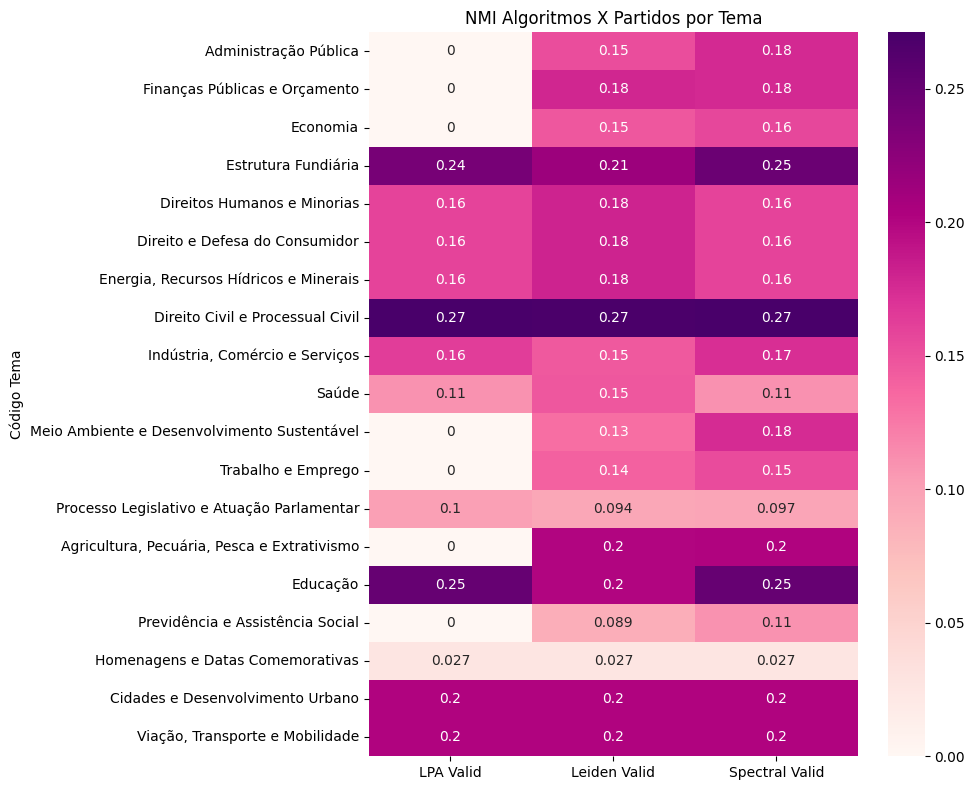

In [42]:
df_nmi_parties = pd.DataFrame(nmi_parties_results).set_index('Theme')

plt.figure(figsize=(10, 8))
sns.heatmap(df_nmi_parties, annot=True, cmap='RdPu')
plt.title("NMI Algoritmos X Partidos por Tema")
plt.ylabel("Código Tema")
plt.tight_layout()
plt.show()

## Mapping Coalitions (Label Grouping)

Para balancear a métrica de NMI, agruparemos os partidos listados na base pelas coligações estruturais de governo. 

In [ ]:
coalitions = {
    'Base do Governo': ['PT', 'PCdoB', 'PV', 'PSB', 'PDT', 'PSOL', 'REDE', 'AVANTE', 'SOLIDARIEDADE'],
    'Independente': ['MDB', 'PSD', 'PP', 'UNIÃO', 'REPUBLICANOS', 'PODE', 'PRD', 'S.PART.'],
    'Oposição': ['PL', 'NOVO', 'PSDB', 'CIDADANIA']
}

party_to_coalition_id = {}
for coal_id, (coal_name, parties) in enumerate(coalitions.items()):
    for party in parties:
        party_to_coalition_id[party] = coal_id

node_to_coalition_id = {}
for node_id, party_idx in node_to_party_id.items():
    party_name = unique_parties[party_idx]
    
    if party_name in party_to_coalition_id:
        node_to_coalition_id[node_id] = party_to_coalition_id[party_name]
    else:
        node_to_coalition_id[node_id] = -1 
        
node_to_coalition_id

{'d_204427': 2,
 'd_74044': 1,
 'd_204450': 1,
 'd_160527': 1,
 'd_204356': 1,
 'd_220638': 2,
 'd_220635': 1,
 'd_220659': 1,
 'd_178871': 1,
 'd_220653': 1,
 'd_178884': 1,
 'd_141450': 1,
 'd_231911': 0,
 'd_178954': 1,
 'd_220669': 1,
 'd_220604': 0,
 'd_204540': 1,
 'd_188097': 0,
 'd_220584': 1,
 'd_204573': 1,
 'd_221338': 0,
 'd_205865': 1,
 'd_153423': 1,
 'd_220546': 2,
 'd_178947': 2,
 'd_220592': 1,
 'd_220577': 1,
 'd_220656': 1,
 'd_103758': 1,
 'd_182146': 0,
 'd_128760': 2,
 'd_220596': 2,
 'd_227370': 1,
 'd_213274': 1,
 'd_220539': 1,
 'd_204398': 1,
 'd_204404': 2,
 'd_91228': 0,
 'd_220558': 2,
 'd_123756': 1,
 'd_220692': 1,
 'd_220647': 1,
 'd_204476': 1,
 'd_220686': 0,
 'd_136811': 1,
 'd_204571': 1,
 'd_220576': 1,
 'd_204515': 0,
 'd_73433': 0,
 'd_204388': 2,
 'd_178993': 1,
 'd_220704': 0,
 'd_220590': 1,
 'd_220673': 2,
 'd_220528': 1,
 'd_204482': 1,
 'd_74273': 2,
 'd_220616': 2,
 'd_229432': 1,
 'd_81055': 0,
 'd_204453': 0,
 'd_160641': 0,
 'd_74376': 0

In [ ]:
nmi_coalitions_results = []

for theme in voted_themes.itertuples():
    code_theme = theme.code
    name_theme = theme.theme
    nodes = list(comms_leiden[f'{code_theme}'].keys())

    valid_nodes = [n for n in nodes if n in node_to_coalition_id]
    if not valid_nodes:
        continue
        
    labels_true_coalition = [node_to_coalition_id[n] for n in valid_nodes]
    
    labels_lp = [comms_label.get(f'{code_theme}', {}).get(n, -1) for n in valid_nodes]
    labels_lei = [comms_leiden.get(f'{code_theme}', {}).get(n, -1) for n in valid_nodes]
    labels_spe = [comms_spectral.get(f'{code_theme}', {}).get(n, -1) for n in valid_nodes]
    
    nmi_coalitions_results.append({
        'Theme': name_theme,
        'LPA vs Coalition': normalized_mutual_info_score(labels_true_coalition, labels_lp),
        'Leiden vs Coalition': normalized_mutual_info_score(labels_true_coalition, labels_lei),
        'Spectral vs Coalition': normalized_mutual_info_score(labels_true_coalition, labels_spe)
    })

df_nmi_coalitions = pd.DataFrame(nmi_coalitions_results).set_index('Theme')


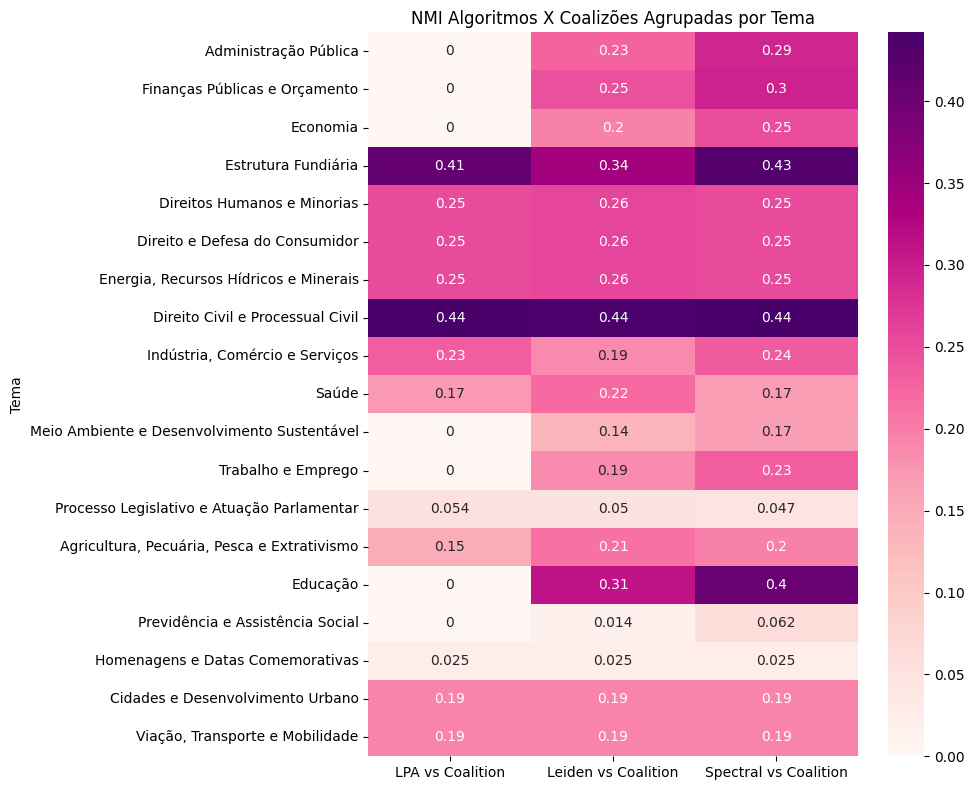

In [44]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_nmi_coalitions, annot=True, cmap='RdPu')
plt.title("NMI Algoritmos X Coalizões Agrupadas por Tema")
plt.ylabel("Tema")
plt.tight_layout()
plt.show()

## Fluidez Ideológica (Comparação com Economia)
Investigar se as bases governistas e oposicionistas votam sempre em bloco indepedentemente do assunto ou se os parlamentares se reagrupam de acordo com o tema. Para isso, vamos fixar o tema "Economia" (40) e usar NMI na inteseção dos deputados para achar similaridades.

In [ ]:
tema_base = '40'

theme_names = {str(row.code): row.theme for row in voted_themes.itertuples()}

fluidity_results = []

for code_theme in comms_leiden.keys():
    if code_theme == tema_base:
        continue
    
    name_theme = theme_names.get(code_theme, f"Tema {code_theme}")

    common_deputies = list(set(comms_leiden[tema_base].keys()) & set(comms_leiden[code_theme].keys()))
    if not common_deputies:
        continue
        
    labels_lpa_base = [comms_label.get(tema_base, {}).get(d, -1) for d in common_deputies]
    labels_lpa_theme = [comms_label.get(code_theme, {}).get(d, -1) for d in common_deputies]
    nmi_lpa = normalized_mutual_info_score(labels_lpa_base, labels_lpa_theme)

    labels_lei_base = [comms_leiden.get(tema_base, {}).get(d, -1) for d in common_deputies]
    labels_lei_theme = [comms_leiden.get(code_theme, {}).get(d, -1) for d in common_deputies]
    nmi_lei = normalized_mutual_info_score(labels_lei_base, labels_lei_theme)

    labels_spe_base = [comms_spectral.get(tema_base, {}).get(d, -1) for d in common_deputies]
    labels_spe_theme = [comms_spectral.get(code_theme, {}).get(d, -1) for d in common_deputies]
    nmi_spe = normalized_mutual_info_score(labels_spe_base, labels_spe_theme)
    
    fluidity_results.append({
        'Theme': name_theme,
        'LPA': nmi_lpa,
        'Leiden': nmi_lei,
        'Spectral': nmi_spe
    })

df_fluidity = pd.DataFrame(fluidity_results).set_index('Theme')

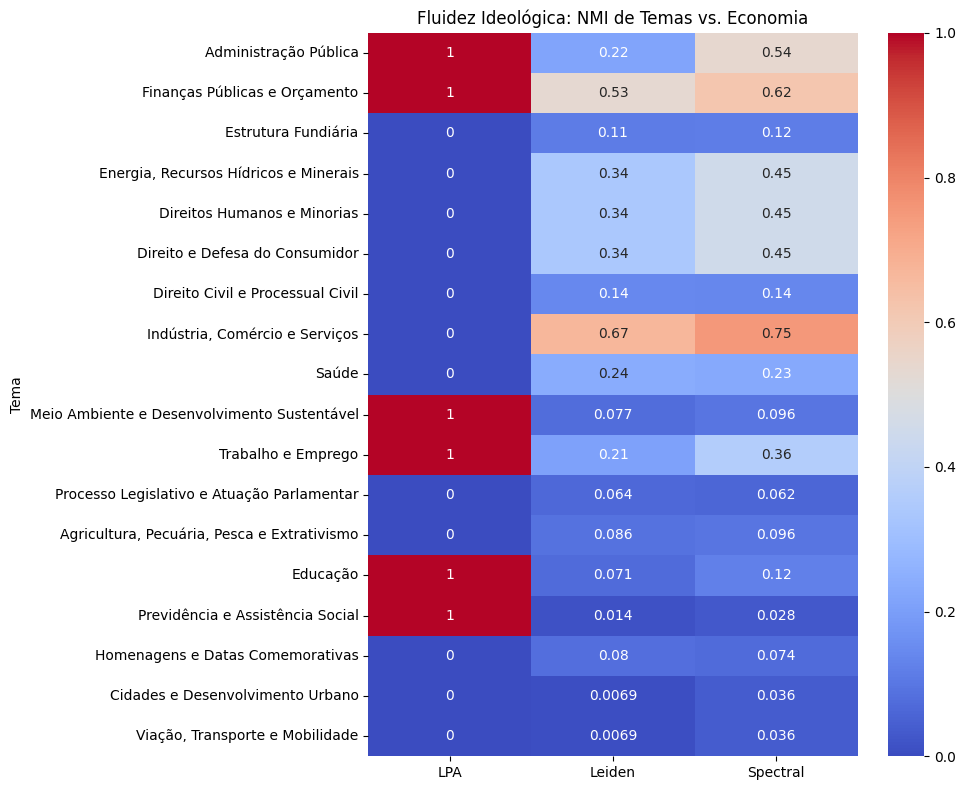

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_fluidity, annot=True, cmap='coolwarm')
plt.title("Fluidez Ideológica: NMI de Temas vs. Economia")
plt.ylabel("Tema")
plt.tight_layout()
plt.show()